# v13 fixed-budget BO (CNR-AUC): pitch the approach, then attack it

Companion analysis to
[bo_erk_oscillation_testv13_auc_fixed_budget.ipynb](bo_erk_oscillation_testv13_auc_fixed_budget.ipynb),
in the same spirit as the
[v11 pitch/critique](bo_v11_pitch_and_critique.ipynb): same data, but the goal
is *to argue* with the run, from the perspective of a reader who knows MAPK,
optogenetic RTKs, and Bayesian optimisation.

**This run is still in progress** — the analysis below is a snapshot. Re-run the
notebook to refresh against the latest checkpoint.

### What v13 changed relative to v11

| | v11 | v13 |
|---|---|---|
| Objective | `frac_responders` (classifier, bounded [0,1]) | `auc_norm` = per-FOV median of per-cell `sum(CNR/baseline - 1)` over stim+recovery, clipped at 0 |
| Oscillation classifier | yes (black box) | **dropped** |
| Search space | `ramp_fraction x pulse_interval`, `pulse_interval in 1..10` | same, but `pulse_interval in 1..20` |
| Light budget | pinned 20 s | pinned **4 s** |
| Covariates | `n_cells, optortk_expression, baseline_cnr` | identical |

So v13 deliberately addresses three v11 critiques: the bounded/saturating
objective (v11 F3), the classifier-as-ground-truth problem (v11 F1), and the
truncated `pulse_interval` range (v11 F2/H2). Good. The point of this notebook
is that those fixes (a) **quietly change the scientific question**, (b)
**introduce a new fixed-budget confound**, and (c) **leave v11's covariate /
replication problems unfixed and in one case deepened**.

Six questions, in order:

1. Where did the BO spend its FOVs?
2. At fixed budget, is `pulse_interval` even a clean axis? (the dose confound)
3. Did BO converge faster than random over the same FOVs?
4. What does the GP claim about the full landscape?
5. Which knobs / covariates does the GP think matter (ARD + CV)?
6. What is `auc_norm` actually rewarding, biologically?

### Caveats up front

1. **One plate.** 5-6 FOVs per condition are *pseudo-replicates* (same plate,
   passage, transfection, imaging window). All confidence statements are
   within-plate.
2. **The run is incomplete** (8 of 13 planned phases at the time of writing),
   so any "optimum" is preliminary and there is no stopping criterion.
3. **The budget is pinned at 4 s and is not searched.** Every conclusion is
   conditional on 4 s being a sensible total dose.
4. **`auc_norm` divides by `baseline_cnr`, which is also a selection criterion,
   a cap, and a BO covariate** — a coupling we examine in Section F.


In [1]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- gpax/numpyro compatibility shim (must run before `import gpax`) ---
# numpyro >= 0.20 removed haiku support; gpax 0.1.9 eagerly imports it via
# gpax/models/__init__.py. We don't use viDKL -- stub the missing names.
# Same shim as the experiment notebook.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError("viDKL is not available with numpyro >= 0.20.")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import gpax
import gpax.utils

gpax.utils.enable_x64()  # gpax 0.1.9 is NaN-prone in float32; match the agent.

from faro.agents.bo_optimization_sparse import _safe_batch_size

EXPERIMENT_PATH = r"E:\Alex\2026-05-20_bo_erk_auc_v13_fixed_budget_4s"
LIGHT_BUDGET_MS = 4000.0  # pinned in the v13 run

# Phase layout from the experiment notebook (needed for the dose confound).
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
FIRST_FRAME_STIM = N_FRAMES_BASELINE  # 10
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM  # 70

# Grid axes as configured in the v13 experiment notebook.
RF_GRID = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 2)  # 11 levels
PI_GRID = np.arange(1, 21, dtype=int)  # {1, ..., 20}
N_GRID_TOTAL = len(RF_GRID) * len(PI_GRID)  # 220

OBJ = "auc_norm"
P1, P2 = "ramp_fraction", "pulse_interval"
COVS = ["n_cells", "optortk_expression", "baseline_cnr"]

print(f"Experiment path: {EXPERIMENT_PATH}")
print(f"Grid:            {len(RF_GRID)} x {len(PI_GRID)} = {N_GRID_TOTAL} conditions")

Experiment path: E:\Alex\2026-05-20_bo_erk_auc_v13_fixed_budget_4s
Grid:            11 x 20 = 220 conditions


In [2]:
# v13 writes a per-FOV `phase_id`, so the cumulative checkpoint is enough --
# no need to diff per-phase files (the v11 trick). Fall back to diffing if the
# column is ever missing.
ckpt = os.path.join(EXPERIMENT_PATH, "bo_results_checkpoint.parquet")
df = pd.read_parquet(ckpt)
if "phase_id" not in df.columns:
    files = sorted(
        glob.glob(
            os.path.join(EXPERIMENT_PATH, "checkpoints", "bo_results_phase_*.parquet")
        )
    )
    chunks, prev = [], 0
    for f in files:
        pid = int(os.path.basename(f).split("_")[-1].split(".")[0])
        cum = pd.read_parquet(f)
        new = cum.iloc[prev:].copy()
        new["phase_id"] = pid
        chunks.append(new)
        prev = len(cum)
    df = pd.concat(chunks, ignore_index=True)

assert (df["light_budget"] == LIGHT_BUDGET_MS).all(), "light_budget drifted!"

n_fovs = len(df)
n_phases = df["phase_id"].nunique()
n_visited = df[[P1, P2]].drop_duplicates().shape[0]

print(
    f"Loaded {n_fovs} FOVs across {n_phases} phases "
    f"(phases {sorted(df['phase_id'].unique())})."
)
print(
    f"Visited conditions: {n_visited} / {N_GRID_TOTAL} "
    f"({100*n_visited/N_GRID_TOTAL:.1f} %)."
)
print(
    f"FOVs per visited condition: mean={n_fovs/n_visited:.1f}, "
    f"min={df.groupby([P1, P2]).size().min()}, "
    f"max={df.groupby([P1, P2]).size().max()}."
)
print(
    f"\n{OBJ}: min={df[OBJ].min():.2f}  median={df[OBJ].median():.2f}  "
    f"mean={df[OBJ].mean():.2f}  max={df[OBJ].max():.2f}"
)
print(
    f"FOVs with {OBJ} <= 0: {(df[OBJ] <= 0).sum()} "
    f"({100*(df[OBJ] <= 0).mean():.1f} %)  "
    f"--> unlike v11's frac_responders, the objective is NOT bottoming out."
)

Loaded 221 FOVs across 13 phases (phases [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]).
Visited conditions: 39 / 220 (17.7 %).
FOVs per visited condition: mean=5.7, min=5, max=6.

auc_norm: min=0.40  median=21.68  mean=22.81  max=56.04
FOVs with auc_norm <= 0: 0 (0.0 %)  --> unlike v11's frac_responders, the objective is NOT bottoming out.


## A -- Where did the BO spend its FOVs?

At a 5-6 FOV/condition budget, a uniform grid scan would put ~0.6 FOVs on each
of the 220 cells. The BO instead concentrates on a handful of conditions. The
question (as in v11) is whether the skipped cells were dead zones.

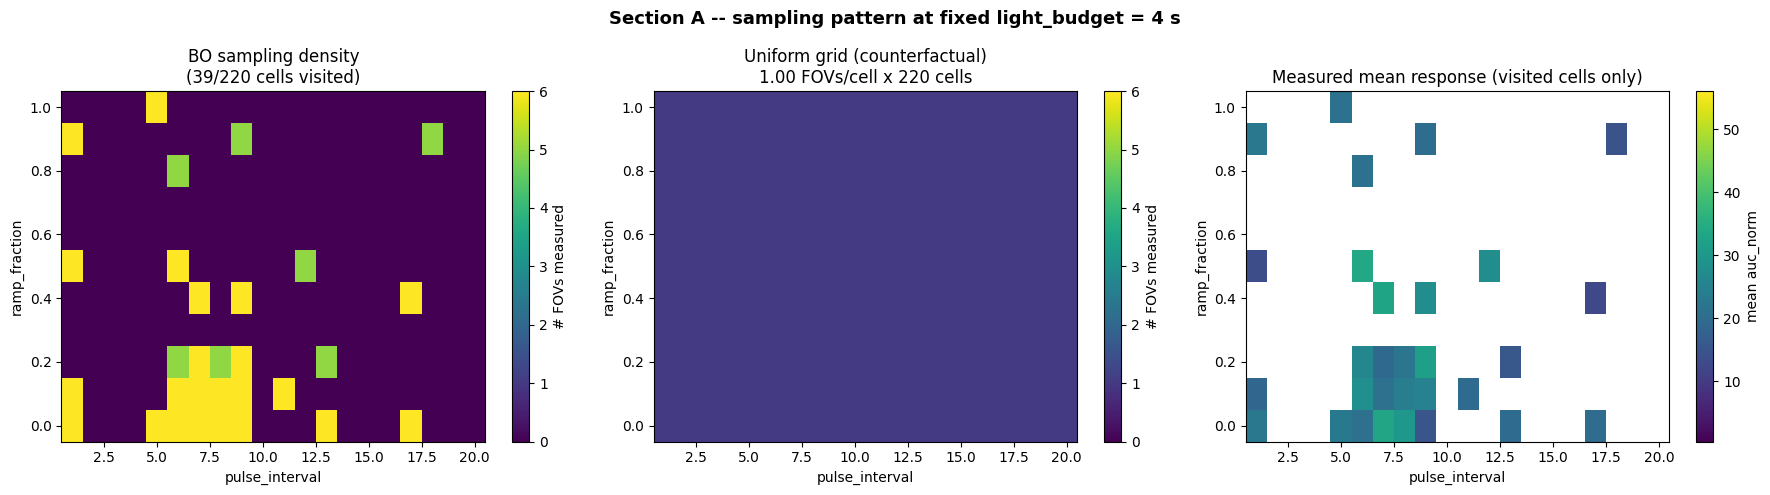

FOVs at pulse_interval = 1 (near-continuous, ~67 ms/pulse): 35/221 (15.8 %)
mean auc_norm at pulse_interval = 1: 19.16  vs overall mean 22.81


In [3]:
fov_count = (
    df.groupby([P1, P2])
    .size()
    .unstack(fill_value=0)
    .reindex(index=RF_GRID, columns=PI_GRID, fill_value=0)
)
fov_mean_obj = (
    df.groupby([P1, P2])[OBJ].mean().unstack().reindex(index=RF_GRID, columns=PI_GRID)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmin, vmax = float(df[OBJ].min()), float(df[OBJ].max())

ax = axes[0]
im = ax.pcolormesh(
    PI_GRID, RF_GRID, fov_count.values, cmap="viridis", shading="nearest"
)
fig.colorbar(im, ax=ax, label="# FOVs measured")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title(f"BO sampling density\n({n_visited}/{N_GRID_TOTAL} cells visited)")

ax = axes[1]
per_cell = n_fovs / N_GRID_TOTAL
im = ax.pcolormesh(
    PI_GRID,
    RF_GRID,
    np.full((len(RF_GRID), len(PI_GRID)), per_cell),
    cmap="viridis",
    shading="nearest",
    vmin=0,
    vmax=fov_count.values.max(),
)
fig.colorbar(im, ax=ax, label="# FOVs measured")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title(
    f"Uniform grid (counterfactual)\n{per_cell:.2f} FOVs/cell x {N_GRID_TOTAL} cells"
)

ax = axes[2]
im = ax.pcolormesh(
    PI_GRID,
    RF_GRID,
    fov_mean_obj.values,
    cmap="viridis",
    shading="nearest",
    vmin=vmin,
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label=f"mean {OBJ}")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("Measured mean response (visited cells only)")

fig.suptitle(
    "Section A -- sampling pattern at fixed light_budget = 4 s",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

n_pi1 = int((df[P2] == 1).sum())
print(
    f"FOVs at pulse_interval = 1 (near-continuous, ~67 ms/pulse): "
    f"{n_pi1}/{n_fovs} ({100*n_pi1/n_fovs:.1f} %)"
)
print(
    f"mean {OBJ} at pulse_interval = 1: {df.loc[df[P2]==1, OBJ].mean():.2f}  "
    f"vs overall mean {df[OBJ].mean():.2f}"
)

### Reading section A

- The BO concentrates in a low-`ramp_fraction`, mid-`pulse_interval` band -- the
  same qualitative story as v11 (it buys replicates where the response lives).
- **But note how much budget still lands at `pulse_interval = 1`.** In v11 that
  was the receptor-internalisation dead zone. In v13 at a 4 s budget, `pi = 1`
  is 60 pulses of ~67 ms -- a near-continuous *low* dose. Whether that is a dead
  zone or a genuinely good "sustained low drive" depends entirely on the
  objective, which is the subject of Section B and Section F.

## B -- At fixed budget, `pulse_interval` is not a clean frequency axis

This is the v13-specific structural problem. The budget reparameterisation sets
the per-pulse base exposure to

`base = light_budget * (1 - ramp_fraction) / n_pulses`,   `n_pulses = len(range(first_frame_stim, last_frame_stim, pulse_interval))`.

So at a **fixed** budget, increasing `pulse_interval` mechanically *increases*
the energy per pulse (fewer pulses share the same 4 s). The BO axis labelled
"pulse_interval" therefore moves *frequency* and *per-pulse amplitude* together.
Any "optimum in `pulse_interval`" conflates "this inter-pulse spacing is best"
with "this per-pulse dose is best" -- they cannot be separated from this design.

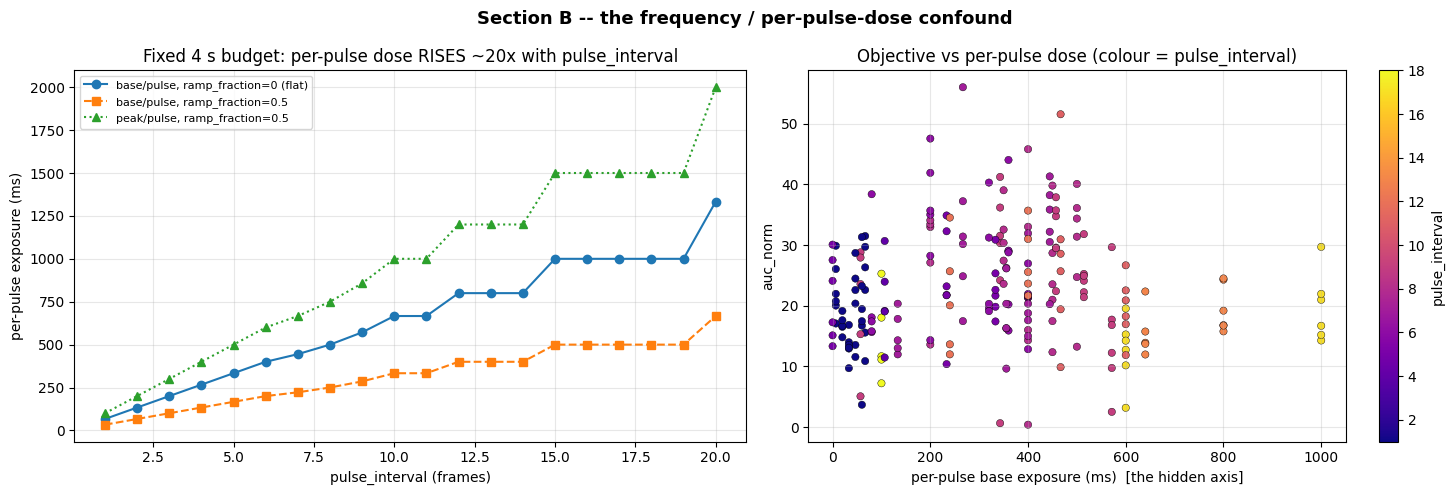

per-pulse base exposure spans 67 ms (pi=1) to 1333 ms (pi=20) at fixed budget -- a 20x range that co-varies with pulse_interval.


In [4]:
def n_pulses(pi):
    return len(range(FIRST_FRAME_STIM, LAST_FRAME_STIM, int(pi)))


def base_peak(pi, rf, budget=LIGHT_BUDGET_MS):
    n = n_pulses(pi)
    if n <= 0:
        return 0.0, 0.0
    if n == 1:
        return float(budget), float(budget)
    base = budget * (1.0 - rf) / n
    ramp = 2.0 * budget * rf / (n * (n - 1))
    return base, base + ramp * (n - 1)


pis = PI_GRID
base0 = np.array([base_peak(pi, 0.0)[0] for pi in pis])  # flat (rf=0)
base5, peak5 = np.array([base_peak(pi, 0.5) for pi in pis]).T  # rf=0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(pis, base0, "o-", label="base/pulse, ramp_fraction=0 (flat)")
ax.plot(pis, base5, "s--", label="base/pulse, ramp_fraction=0.5")
ax.plot(pis, peak5, "^:", label="peak/pulse, ramp_fraction=0.5")
ax.set_xlabel("pulse_interval (frames)")
ax.set_ylabel("per-pulse exposure (ms)")
ax.set_title("Fixed 4 s budget: per-pulse dose RISES ~20x with pulse_interval")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Does the measured objective track frequency or per-pulse dose?
ax = axes[1]
df_base = df.assign(base_ms=[base_peak(pi, rf)[0] for pi, rf in zip(df[P2], df[P1])])
sc = ax.scatter(
    df_base["base_ms"],
    df_base[OBJ],
    c=df_base[P2],
    cmap="plasma",
    s=28,
    edgecolors="k",
    linewidths=0.3,
)
fig.colorbar(sc, ax=ax, label="pulse_interval")
ax.set_xlabel("per-pulse base exposure (ms)  [the hidden axis]")
ax.set_ylabel(OBJ)
ax.set_title("Objective vs per-pulse dose (colour = pulse_interval)")
ax.grid(alpha=0.3)

fig.suptitle(
    "Section B -- the frequency / per-pulse-dose confound",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(
    f"per-pulse base exposure spans {base0.min():.0f} ms (pi=1) "
    f"to {base0.max():.0f} ms (pi={int(pis[-1])}) at fixed budget -- a "
    f"{base0.max()/base0.min():.0f}x range that co-varies with pulse_interval."
)

### Reading section B

- The left panel shows the trap: along the `pulse_interval` axis the per-pulse
  dose rises from ~67 ms to ~1.3 s -- a ~20x amplitude sweep wearing a
  frequency label. `ramp_fraction` adds a second amplitude knob on top.
- The right panel is the diagnostic: if `auc_norm` lines up with the *per-pulse
  base exposure* more cleanly than with `pulse_interval` itself, the BO is
  really doing per-pulse **dose-response**, not **frequency** tuning.
- This is not a bug in the code -- it is the unavoidable cost of pinning the
  budget and reparameterising. It just means the headline "best pulse_interval"
  is **not** interpretable as a biological frequency preference.

## C -- Did BO converge faster than random over the same FOVs?

Same construction as the v11 notebook: cumulative best mean-per-condition over
FOV index, BO order vs many random reorderings of the *same* FOVs. A condition's
mean only counts once it has >= 3 FOVs (otherwise a lucky single FOV saturates
the metric).

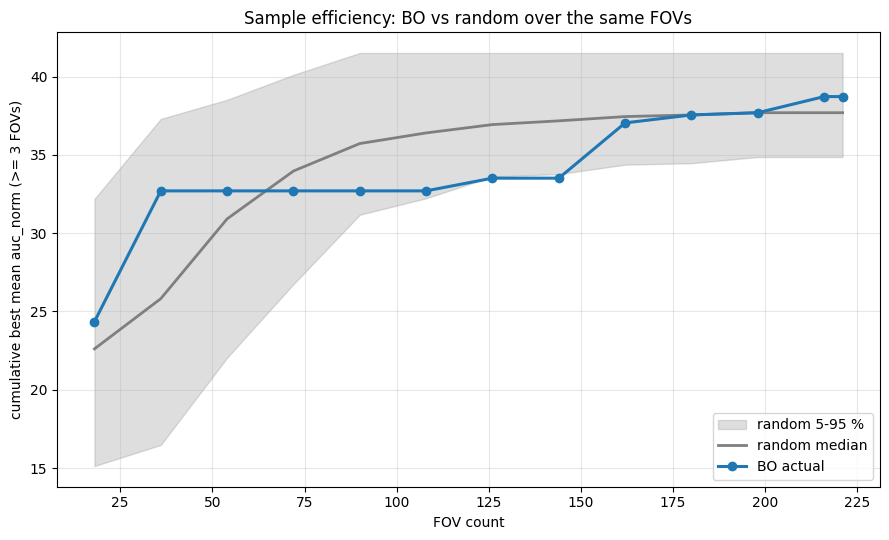

BO best mean-per-condition: 38.72
FOVs to reach 80 % of final (30.98):  BO=36  random_median=72


In [5]:
MIN_FOVS_FOR_CRED = 3


def cumulative_best_by_fovs(
    df_sorted, obj=OBJ, granularity=18, min_replicates=MIN_FOVS_FOR_CRED
):
    cum_best, cond_running, cur_best, idxs = [], {}, -np.inf, []
    n = len(df_sorted)
    for i, row in enumerate(df_sorted.itertuples(index=False)):
        key = (getattr(row, P1), getattr(row, P2))
        cond_running.setdefault(key, []).append(getattr(row, obj))
        if len(cond_running[key]) >= min_replicates:
            cur_best = max(cur_best, float(np.mean(cond_running[key])))
        if (i + 1) % granularity == 0 or i == n - 1:
            cum_best.append(cur_best if np.isfinite(cur_best) else np.nan)
            idxs.append(i + 1)
    return np.array(idxs), np.array(cum_best)


df_bo = df.sort_values(["phase_id", "fov"]).reset_index(drop=True)
idx_bo, traj_bo = cumulative_best_by_fovs(df_bo)

rng = np.random.default_rng(0)
rand = np.stack(
    [
        cumulative_best_by_fovs(
            df.iloc[rng.permutation(len(df))].reset_index(drop=True)
        )[1]
        for _ in range(100)
    ]
)
rand_med = np.nanmedian(rand, axis=0)
rand_lo, rand_hi = np.nanpercentile(rand, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(
    idx_bo, rand_lo, rand_hi, color="tab:gray", alpha=0.25, label="random 5-95 %"
)
ax.plot(idx_bo, rand_med, color="tab:gray", lw=2, label="random median")
ax.plot(idx_bo, traj_bo, "o-", color="tab:blue", lw=2.2, ms=6, label="BO actual")
ax.set_xlabel("FOV count")
ax.set_ylabel(f"cumulative best mean {OBJ} (>= {MIN_FOVS_FOR_CRED} FOVs)")
ax.set_title("Sample efficiency: BO vs random over the same FOVs")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final = traj_bo[-1]
thr = 0.8 * final
hit = lambda t: int(idx_bo[np.argmax(t >= thr)]) if (t >= thr).any() else None
print(f"BO best mean-per-condition: {final:.2f}")
print(
    f"FOVs to reach 80 % of final ({thr:.2f}):  BO={hit(traj_bo)}  random_median={hit(rand_med)}"
)

### Reading section C

Read this exactly as cautiously as in v11. With the same-FOV-pool construction
random search keeps an artificially strong hand (it cannot draw the unvisited
bad cells), so "BO ~ random median" here is the *expected* honest outcome, not a
failure. What BO clearly bought is **not** spending wet-lab time on the ~200
unvisited cells. What it does **not** prove (from this data, no grid arm) is
faster peak-finding. And with the run incomplete, the trajectory has not
plateaued -- there is still no stopping criterion (v11 F9, unfixed).

## D -- What did the GP learn about cells it never measured?

Refit an independent `gpax.ExactGP` on all FOVs (control + covariates), predict
on the full 220-cell grid marginalised over the empirical covariate
distribution. `auc_norm` is unbounded above, so -- unlike v11's bounded
`frac_responders` -- we fit it on the raw scale (no logit), exactly as the agent
does.

In [6]:
from sklearn.preprocessing import StandardScaler

x_raw = df[[P1, P2] + COVS].to_numpy(dtype=float)
y_raw = df[OBJ].to_numpy(dtype=float)
sx = StandardScaler().fit(x_raw)
sy = StandardScaler().fit(y_raw.reshape(-1, 1))
X = sx.transform(x_raw)
y = sy.transform(y_raw.reshape(-1, 1)).ravel()

rk, rkp = gpax.utils.get_keys()
gp = gpax.ExactGP(input_dim=X.shape[1], kernel="Matern")
print("Fitting ExactGP on full BO data (~30 s) ...")
gp.fit(
    rk,
    X,
    y,
    num_warmup=500,
    num_samples=800,
    num_chains=1,
    print_summary=False,
    progress_bar=False,
)

N_COV = 80
rm = np.random.default_rng(0)
cov_samples = df[COVS].to_numpy(dtype=float)[rm.integers(0, len(df), N_COV)]
ctrl = np.array([[r, p] for r in RF_GRID for p in PI_GRID], dtype=float)
x_full = np.hstack([np.repeat(ctrl, N_COV, 0), np.tile(cov_samples, (len(ctrl), 1))])
Xf = sx.transform(x_full)
bs = _safe_batch_size(Xf.shape[0], 256)
yp_s, ys_s = gp.predict_in_batches(rkp, Xf, batch_size=bs, noiseless=True)
yp = sy.inverse_transform(np.asarray(yp_s).reshape(-1, 1)).ravel()
ystd = np.asarray(ys_s).reshape(-1, Xf.shape[0]).std(0) * sy.scale_[0]

Y_mean = yp.reshape(len(ctrl), N_COV).mean(1).reshape(len(RF_GRID), len(PI_GRID))
Y_std = ystd.reshape(len(ctrl), N_COV).mean(1).reshape(len(RF_GRID), len(PI_GRID))
ri, pi_ = np.unravel_index(int(np.argmax(Y_mean)), Y_mean.shape)
opt_rf, opt_pi, opt_pred = float(RF_GRID[ri]), int(PI_GRID[pi_]), float(Y_mean[ri, pi_])
print(
    f"GP-predicted optimum: ramp_fraction={opt_rf:.2f}, pulse_interval={opt_pi}, "
    f"predicted {OBJ}={opt_pred:.2f}"
)

Fitting ExactGP on full BO data (~30 s) ...
GP-predicted optimum: ramp_fraction=0.00, pulse_interval=7, predicted auc_norm=26.26


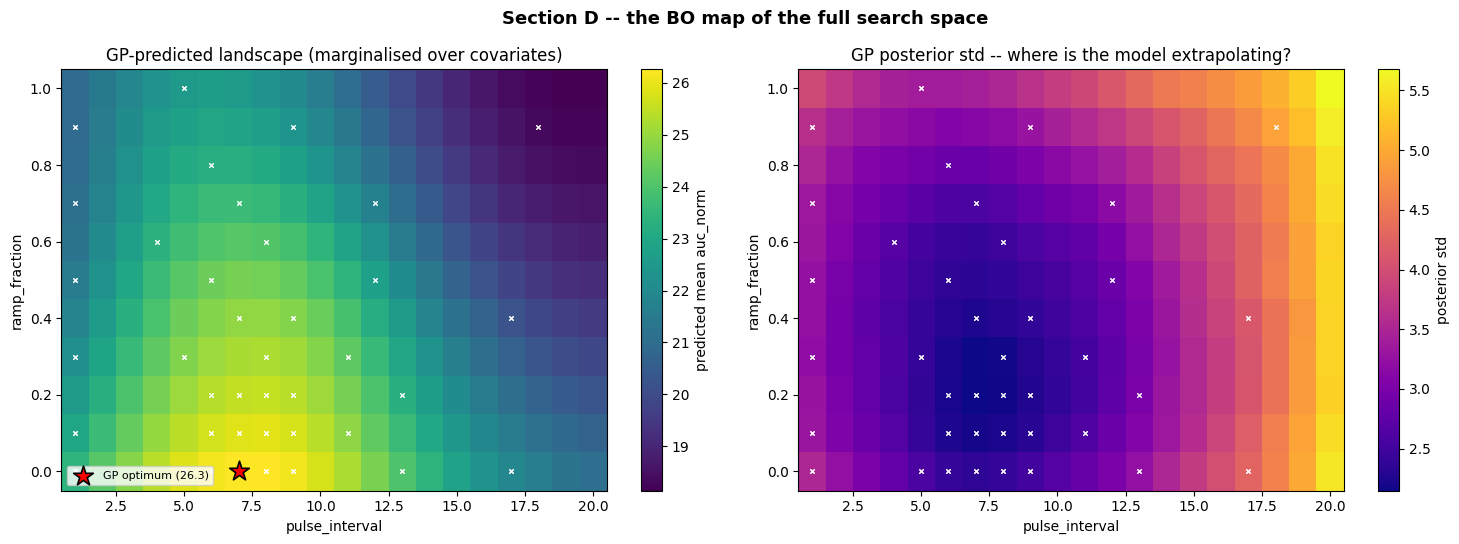

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
im = ax.pcolormesh(PI_GRID, RF_GRID, Y_mean, cmap="viridis", shading="nearest")
fig.colorbar(im, ax=ax, label=f"predicted mean {OBJ}")
ax.scatter(df[P2], df[P1], c="white", s=10, alpha=0.6, marker="x", linewidths=0.7)
ax.scatter(
    [opt_pi],
    [opt_rf],
    c="red",
    s=220,
    marker="*",
    edgecolors="k",
    linewidths=1.2,
    zorder=10,
    label=f"GP optimum ({opt_pred:.1f})",
)
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("GP-predicted landscape (marginalised over covariates)")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
im = ax.pcolormesh(PI_GRID, RF_GRID, Y_std, cmap="plasma", shading="nearest")
fig.colorbar(im, ax=ax, label="posterior std")
ax.scatter(df[P2], df[P1], c="white", s=10, alpha=0.6, marker="x", linewidths=0.7)
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("GP posterior std -- where is the model extrapolating?")
fig.suptitle(
    "Section D -- the BO map of the full search space", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### Reading section D

- The high-`auc_norm` ridge sits at low `ramp_fraction` across a broad
  `pulse_interval` band -- consistent with the live BO picks. Translate the
  `pulse_interval` axis through Section B before calling it a "frequency"
  result.
- The std map shows the usual story: confident only where FOVs were spent;
  everywhere else the prediction is mostly prior. A grid scan would give the
  same map with smaller std in the cells it actually paid to measure. The BO
  argument is "same map of the cells that matter, at ~1/9th of the cells
  visited", not "a better map".

## E -- Which knobs and covariates does the GP think matter?

Two diagnostics: (1) ARD lengthscales from the saved final GP (short
lengthscale = relevant axis); (2) 5-fold CV RMSE with vs without the covariates.
If `ramp_fraction` has a long lengthscale, one of the two BO axes is nearly
inert for this objective.

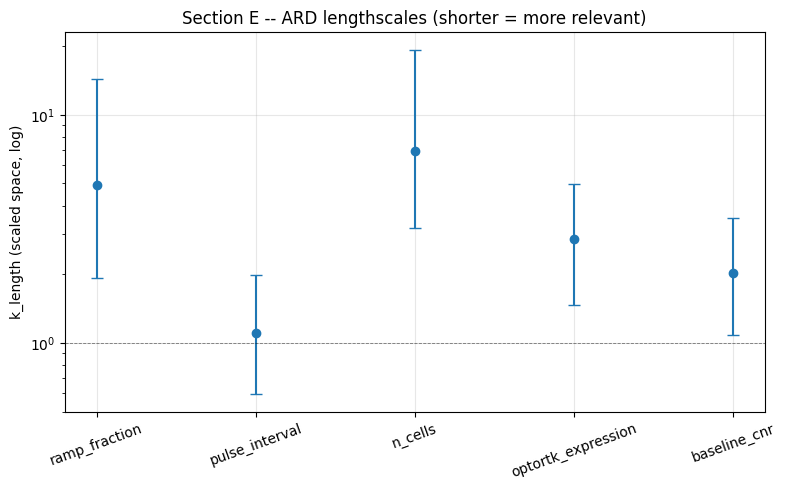

  ramp_fraction          (BO knob ): k_length=  4.94  relevance(1/k)=0.203
  pulse_interval         (BO knob ): k_length=  1.10  relevance(1/k)=0.909
  n_cells                (covariate): k_length=  6.91  relevance(1/k)=0.145
  optortk_expression     (covariate): k_length=  2.87  relevance(1/k)=0.349
  baseline_cnr           (covariate): k_length=  2.02  relevance(1/k)=0.496


In [8]:
mfiles = sorted(
    glob.glob(os.path.join(EXPERIMENT_PATH, "models", "bo_model_iter_*.joblib"))
)
payload = joblib.load(mfiles[-1])
ms = payload["model_state"]
names = payload["parameter_names"] + payload["covariate_names"]
kl = np.asarray(ms["samples"]["k_length"])
k_med = np.median(kl, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
xp = np.arange(len(names))
ax.errorbar(
    xp,
    k_med,
    yerr=[k_med - np.quantile(kl, 0.05, 0), np.quantile(kl, 0.95, 0) - k_med],
    fmt="o",
    capsize=4,
    color="tab:blue",
)
ax.set_yscale("log")
ax.set_xticks(xp)
ax.set_xticklabels(names, rotation=20)
ax.axhline(1.0, color="k", lw=0.6, ls="--", alpha=0.5)
ax.set_ylabel("k_length (scaled space, log)")
ax.set_title("Section E -- ARD lengthscales (shorter = more relevant)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for n, lm in zip(names, k_med):
    kind = "BO knob " if n in payload["parameter_names"] else "covariate"
    print(f"  {n:<22s} ({kind}): k_length={lm:6.2f}  relevance(1/k)={1.0/lm:.3f}")

In [9]:
# 5-fold CV RMSE, control-only vs control+covariates (raw auc_norm, no logit).
from sklearn.model_selection import KFold


def cv_gp_rmse(Xr, yr, n_splits=5, seed=11):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rmses = []
    for tr, te in kf.split(Xr):
        sxf = StandardScaler().fit(Xr[tr])
        syf = StandardScaler().fit(yr[tr].reshape(-1, 1))
        Xtr, Xte = sxf.transform(Xr[tr]), sxf.transform(Xr[te])
        ytr = syf.transform(yr[tr].reshape(-1, 1)).ravel()
        a, b = gpax.utils.get_keys()
        g = gpax.ExactGP(input_dim=Xtr.shape[1], kernel="Matern")
        g.fit(
            a,
            Xtr,
            ytr,
            num_warmup=400,
            num_samples=600,
            num_chains=1,
            print_summary=False,
            progress_bar=False,
        )
        yh, _ = g.predict_in_batches(
            b, Xte, batch_size=_safe_batch_size(len(Xte), 2000), n=1, noiseless=True
        )
        yh = syf.inverse_transform(np.asarray(yh).reshape(-1, 1)).ravel()
        rmses.append(float(np.sqrt(np.mean((yr[te] - yh) ** 2))))
    return float(np.mean(rmses)), float(np.std(rmses))


yv = df[OBJ].to_numpy(float)
cv_a, sd_a = cv_gp_rmse(df[[P1, P2]].to_numpy(float), yv)
cv_b, sd_b = cv_gp_rmse(df[[P1, P2] + COVS].to_numpy(float), yv)
print(f"CV RMSE  control-only      : {cv_a:.2f} +/- {sd_a:.2f}")
print(f"CV RMSE  control+covariates: {cv_b:.2f} +/- {sd_b:.2f}")
gain = 100 * (cv_a - cv_b) / cv_a if cv_a else 0.0
print(f"covariate gain on CV: {cv_a - cv_b:+.2f} ({gain:+.1f} % relative)")
print(
    "=> covariates earn their place"
    if gain > 10
    else (
        "=> covariates help marginally"
        if gain > 3
        else "=> covariates barely help on CV (consider dropping the noisiest)"
    )
)

CV RMSE  control-only      : 8.88 +/- 1.40
CV RMSE  control+covariates: 6.72 +/- 1.28
covariate gain on CV: +2.16 (+24.3 % relative)
=> covariates earn their place


### Reading section E

- If `ramp_fraction` shows a long lengthscale (and the live BO keeps picking
  `ramp_fraction = 0`), then **one of the two BO axes is nearly inert** for
  `auc_norm`: redistributing a fixed budget over time barely changes the
  integral of an roughly-monotone response. A 2-D search where one axis does
  little is wasted modelling capacity -- the budget could fund a second
  *informative* axis (e.g. the total budget itself).
- The covariate CV result should be read against the collider warning in
  Section F: `baseline_cnr` is conditioned on at FOV selection and divides the
  objective, so any apparent `baseline_cnr` signal is partly mechanical.

## F -- What is `auc_norm` actually rewarding?

`auc_norm` (per cell) = `sum_t (CNR_t / baseline_cell - 1)` over the stim +
recovery window, clipped at 0, then **median across cells** per FOV. Three
properties worth staring at:

1. It rewards **integrated, sustained** ERK elevation -- not oscillation. A
   trace that stays high scores higher than one that oscillates back to
   baseline. **v13 has quietly stopped optimising for oscillation.** If
   sustained activity is the goal, fine; if oscillation is still the goal, the
   objective is misaligned and the classifier should not have been dropped.
2. It **divides by `baseline_cell`**, and baseline is simultaneously (a) the FOV
   selection criterion (`cnr < 0.95` in >= 75 % of cells), (b) capped
   (`max_baseline_cnr = 1.0`), and (c) a BO covariate. Normalising by a
   selected-on, capped variable couples the objective to the screening pipeline.
3. The **median** across cells discards heterogeneity: a condition where a few
   cells respond enormously scores *lower* than one where most cells respond
   mildly. That is a deliberate "fraction that responds" bias, and it throws
   away the cell-to-cell variation that optoRTK expression is supposed to
   explain.

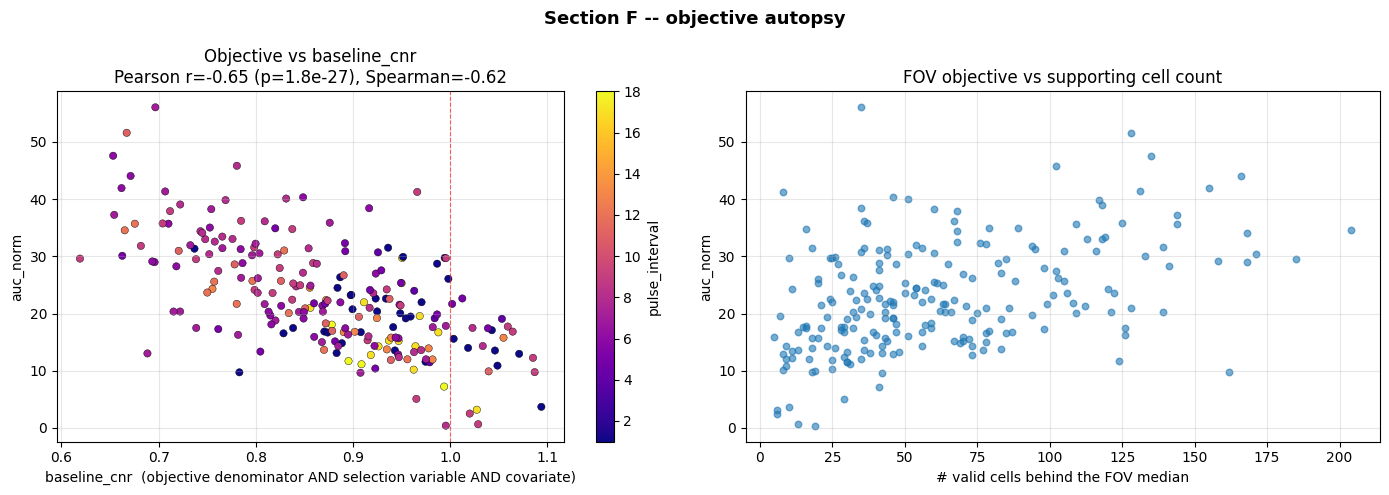

baseline_cnr range in data: 0.619 .. 1.094  (cap = max_baseline_cnr = 1.0)
valid-cell count behind a FOV value: min=5, median=51, max=204


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Objective vs its own denominator -- is auc_norm just tracking baseline?
ax = axes[0]
sc = ax.scatter(
    df["baseline_cnr"],
    df[OBJ],
    c=df[P2],
    cmap="plasma",
    s=28,
    edgecolors="k",
    linewidths=0.3,
)
fig.colorbar(sc, ax=ax, label="pulse_interval")
from scipy.stats import pearsonr, spearmanr

pr, pp = pearsonr(df["baseline_cnr"], df[OBJ])
sr, sp = spearmanr(df["baseline_cnr"], df[OBJ])
ax.set_xlabel(
    "baseline_cnr  (objective denominator AND selection variable AND covariate)"
)
ax.set_ylabel(OBJ)
ax.set_title(
    f"Objective vs baseline_cnr\nPearson r={pr:+.2f} (p={pp:.2g}), Spearman={sr:+.2f}"
)
ax.axvline(1.0, color="r", ls="--", lw=0.8, alpha=0.6)  # the cap
ax.grid(alpha=0.3)

# (2) How many cells actually back each FOV value?
ax = axes[1]
ax.scatter(df["n_valid_cells_auc_norm"], df[OBJ], s=22, alpha=0.6, c="tab:blue")
ax.set_xlabel("# valid cells behind the FOV median")
ax.set_ylabel(OBJ)
ax.set_title("FOV objective vs supporting cell count")
ax.grid(alpha=0.3)

fig.suptitle("Section F -- objective autopsy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(
    f"baseline_cnr range in data: {df['baseline_cnr'].min():.3f} .. "
    f"{df['baseline_cnr'].max():.3f}  (cap = max_baseline_cnr = 1.0)"
)
print(
    f"valid-cell count behind a FOV value: min={int(df['n_valid_cells_auc_norm'].min())}, "
    f"median={int(df['n_valid_cells_auc_norm'].median())}, "
    f"max={int(df['n_valid_cells_auc_norm'].max())}"
)

### Reading section F

- A strong negative `auc_norm` vs `baseline_cnr` correlation would be partly
  *mechanical* (baseline is the denominator), not biology -- so it cannot be
  used to argue "low-baseline cells respond more".
- Some FOV values are backed by very few valid cells (see the left tail of the
  right panel); those medians are noisy and the GP treats them with the same
  Gaussian noise as a 200-cell FOV.

## G -- Things I am unhappy about (v13-specific)

Each bullet is a defect of *this* run. v13 fixed real v11 problems; these are
what it introduced or left standing.

### G1. The objective silently changed the question from oscillation to integrated activity
`auc_norm` integrates CNR above baseline; it is maximised by **sustained**
drive, and a true oscillation (dipping to baseline) scores *worse* than a flat
elevated trace. The classifier that actually measured oscillation was dropped.
If the program goal is still "find oscillatory regimes," v13 is optimising the
wrong thing; if the goal is now "maximise integrated ERK per fixed dose," say so
explicitly, because it is a different paper.

### G2. Fixed budget confounds frequency with per-pulse dose (Section B)
At 4 s pinned, `base = 4000*(1-rf)/n_pulses`, so per-pulse dose rises ~20x
across the `pulse_interval` axis. The "best pulse_interval" is not a frequency
preference -- it is inseparable from a per-pulse dose-response. A clean design
needs either a fixed *per-pulse* dose with variable budget, or budget as an
explicit axis.

### G3. The objective is normalised by a selected-on, capped covariate (Section F)
Dividing per-cell AUC by `baseline_cell`, while `baseline_cnr` is the FOV
screening criterion, is capped at 1.0, and is a BO covariate, couples the
objective to the selection pipeline. The intended fix (remove the
baseline-magnitude confound) trades one confound for a worse one. Decouple them:
screen on something other than CNR, or do not regress on what you normalise by.

### G4. Collider bias on `baseline_cnr` -- unfixed from v11 and now deepened
v11 F6 already flagged that conditioning on `baseline_cnr` at selection while
using it as a regressor induces spurious covariate-outcome associations. v13
adds it to the *objective's denominator*. The Section E covariate result for
`baseline_cnr` is uninterpretable as biology.

### G5. The budget (4 s) is an unsearched, unjustified hyperparameter
The series has now pinned 20 s, 10 s, and 4 s without searching it. Everything
here is conditional on 4 s being a sensible dose. If 4 s is sub-threshold, the
landscape is "how best to spend a too-small budget" and the optimum is an
artefact of the budget choice.

### G6. One of the two BO axes may be inert (Section E)
If `ramp_fraction` has a long lengthscale and the picks cluster at
`ramp_fraction = 0`, the 2-D search is effectively 1-D. For an integral
objective, *when* you deliver a fixed dose barely matters. That modelling
budget would be better spent on an axis that moves the objective (the total
budget).

### G7. FOV-median throws away the responder distribution (Section F)
Median-across-cells with per-cell clip-at-0 rewards "many cells respond a
little" over "few cells respond a lot," and discards exactly the cell-level
heterogeneity that `optortk_expression` is meant to explain. A
mean / high-quantile, or a hierarchical cell~FOV~condition model, would use it.

### G8. Pseudo-replicates and a single plate -- unfixed from v11
5-6 FOVs/condition on one plate, one passage, one transfection, one imaging
window. Reported GP std is a within-plate number; across-plate replication is
not estimated.

### G9. No stopping criterion; run is incomplete
8 of 13 phases. The acquisition is already in exploitation around the ridge but
keeps drawing nearby conditions. As in v11 F9, there is no
"predicted-optimum-stable-for-k-phases" stop, so phases are spent confirming a
known peak.

### G10. Live-plot axis mislabelling (repro/methodology)
The inherited `OscillationBO` live plot labels the landscape/acquisition axes
`stim_exposure / ramp` (the v11 derived parameters), not
`ramp_fraction / pulse_interval`. On v13 those derived quantities live on a
totally different scale, so the in-notebook live panels render misleadingly --
this is why the landscape had to be regenerated post-hoc
([regenerate_live_plot_v13.py](regenerate_live_plot_v13.py)). Cheap to fix in
the plot method; worth doing so the live view is trustworthy.

## H -- The slide-ready pitch (and what I would *not* claim)

**What v13 genuinely improved over v11**
1. **Unbounded, well-spread objective.** `auc_norm` ranges across ~0-46 with no
   pile-up at a ceiling (Section A print-out), so the GP no longer goes
   pathologically confident at a saturated metric (v11 F3 -- fixed).
2. **No classifier black box.** The objective is computed directly from per-cell
   CNR; nothing hides behind a trained model with its own failure modes
   (v11 F1 -- fixed, at the cost of G1).
3. **Wider `pulse_interval` (1-20).** The optimum is interior, not jammed at the
   grid edge as it was in v11 (v11 F1/H2 -- fixed).
4. **Concentration where the response lives.** Same sample-reallocation win as
   v11: replicates bought at the productive ridge, ~200 cells never paid for.

**What I would NOT put on a slide**
- "v13 found the best oscillation setting." It does not measure oscillation
  (G1).
- "pulse_interval = X min is the optimal frequency." It is confounded with
  per-pulse dose (G2).
- "low-baseline cells respond more" / any `baseline_cnr` covariate story (G3,
  G4 -- mechanical + collider).
- "The optimum is established." Run is incomplete, one plate, budget pinned
  (G5, G8, G9).
- "Both BO knobs matter." `ramp_fraction` may be inert (G6).

## I -- Concrete diffs for the next run

Ranked by payoff per unit effort.

### Tier 1 -- decide the question and remove the worst confounds
1. **State the objective's intent.** If oscillation is the goal, bring back an
   oscillation metric (or add it alongside `auc_norm`). If integrated activity
   is the goal, rename the experiment and stop framing it as oscillation (G1).
2. **Break the frequency / dose confound (G2).** Either (a) fix the *per-pulse*
   dose and let the budget float, or (b) make `light_budget` an explicit BO axis
   and keep `auc_per_light` as the objective (the v12 idea). A 3-D
   `(light_budget, pulse_interval, ramp_fraction)` BO is the natural end state.
3. **Decouple the objective from the screen (G3, G4).** Screen FOVs on a
   criterion that is *not* the objective's denominator (e.g. a nuclear-marker
   count or a cell-cycle gate), or drop `baseline_cnr` from the covariates.

### Tier 2 -- modelling
4. **Use cell-level data (G7).** Move to a hierarchical cell~FOV~condition model
   or at least pass per-cell `optortk_expression` quantiles, not the FOV mean.
   Likely sharpens acquisition and uses the heterogeneity you already collect.
5. **Drop or replace `ramp_fraction` if ARD says it is inert (G6).** Free a
   dimension for the budget axis.
6. **Add a stopping criterion (G9).** Stop when the predicted-optimum location
   is unchanged for 3 phases and its predicted mean moves < a set tolerance.

### Tier 3 -- once
7. **Justify or search the 4 s budget (G5).** At minimum run a quick dose
   ladder to confirm 4 s is above activation threshold before optimising how to
   spend it.
8. **Two plates, different days (G8).** Pool with a plate-level random effect to
   get a credible across-plate interval.
9. **Fix the live-plot axis labels (G10).** One-line change in
   `OscillationBO._plot_landscape_and_acq_from_context`.